# MP2

In [2]:
from pyscf import gto, scf, mp
import numpy as np
from Dev.CSMP2_dev import CS_MP2
from Dev.naive_MP2 import CS_MP2 as naive_CS_MP2
from py_mods.src.SCF.CSRHF import CS_RHF, CS_RHF_ContextClass
from py_mods.src.SCF.external import RHF_context_from_pyscf
import matplotlib.pyplot as plt

In [3]:
# pyscf data
pyscf_args = {
    "atom": "He 0 0 0",
    "spin": 0,
    "charge": 0,
    "basis": "aug-cc-pvqz",
}

mol = gto.M(**pyscf_args)

mf = scf.RHF(mol)

e_He = mf.kernel()
e_elec = mf.energy_elec()

mymp = mp.RMP2(mf).run()  # this is UMP2

converged SCF energy = -2.86152199563245
E(RMP2) = -2.89724612518338  E_corr = -0.0357241295509311
E(SCS-RMP2) = -2.90439095109357  E_corr = -0.0428689554611174


In [4]:
# implementation and calculation
RHF_cxt = RHF_context_from_pyscf(**pyscf_args)
RHF_res = CS_RHF(RHF_cxt)

# RHF_res.e_orb = mf.mo_energy
print(f"\nSCF energy: {RHF_res.E_RHF.real} (converged: {RHF_res.converged})")
print(f"SCF pyscf: {e_He}")
print(f"Difference: {RHF_res.E_RHF.real - e_He} \n")


SCF energy: -2.8615219956324673 (converged: True)
SCF pyscf: -2.861521995632451
Difference: -1.6431300764452317e-14 



In [5]:
%%timeit
mp_results = CS_MP2(RHF_res)

# print(f'\n\nMP2 calc: {mp_results.E_MP2}, E_corr = {mp_results.E_corr}')
# print(f'MP2 pyscf: {mymp.e_tot}, E_corr = {mymp.e_corr}')
# print(f'Differences: {mp_results.E_MP2 - mymp.e_tot}, E_corr = {mp_results.E_corr - mymp.e_corr}\n')


796 μs ± 8.92 μs per loop (mean ± std. dev. of 7 runs, 1,000 loops each)


In [6]:
%%timeit
n_mp_results = naive_CS_MP2(RHF_res)

312 ms ± 9.45 ms per loop (mean ± std. dev. of 7 runs, 1 loop each)


In [7]:
mp_results = CS_MP2(RHF_res)
n_mp_results = naive_CS_MP2(RHF_res)

In [8]:
print(
    f"Difference between naive and tensor approach: {n_mp_results.E_MP2 - mp_results.E_MP2}"
)
print(f"\n\nMP2 calc: {mp_results.E_MP2}, E_corr = {mp_results.E_corr}")
print(f"MP2 pyscf: {mymp.e_tot}, E_corr = {mymp.e_corr}")
print(
    f"Differences: {mp_results.E_MP2 - mymp.e_tot}, E_corr = {mp_results.E_corr - mymp.e_corr}"
)

Difference between naive and tensor approach: 0j


MP2 calc: (-2.8957947429693878+0j), E_corr = (-0.03427274733692039-0j)
MP2 pyscf: -2.897246125183382, E_corr = -0.03572412955093114
Differences: (0.0014513822139941013+0j), E_corr = (0.0014513822140107546-0j)


In [9]:
# E_corr_delta is 0.0014513820386715878 using PySCF's Mo energies, that compared with the current approach is
print(
    f"E_corr_delta using PySCFs MO energies: {mp_results.E_corr - mymp.e_corr  - 0.0014513820386715878}"
)
# print(RHF_res.e_orb - mf.mo_energy)

E_corr_delta using PySCFs MO energies: (1.753391667969062e-10-0j)


In [11]:
basis = "aug-cc-pvqz"
pyscf_args = {
    "atom": "He 0 0 0",
    "spin": 0,
    "charge": 0,
    "basis": f"{basis}",
}

atoms = [
    "He 0 0 0",
    "Be 0 0 0",
    "Ne 0 0 0",
    "Mg 0 0 0",
    "Ar 0 0 0",
    "Kr 0 0 0",
]

a_names = [i.strip().split()[0] for i in atoms]

abs_errors = []
rel_errors = []
n_electrons = []

for atom in atoms:
    pyscf_args["atom"] = atom
    mol = gto.M(**pyscf_args)

    mf = scf.RHF(mol)

    e_He = mf.kernel()
    e_elec = mf.energy_elec()

    mymp = mp.RMP2(mf).run()  # this is UMP2

    n_electrons.append(mol.nelectron)

    # implementation and calculation
    RHF_cxt = RHF_context_from_pyscf(**pyscf_args)
    # RHF_cxt.threshold = 1e-7

    RHF_res = CS_RHF(RHF_cxt)
    mp_results = CS_MP2(RHF_res)

    abs_errors.append(mymp.e_tot - mp_results.E_MP2)
    rel_errors.append(np.abs((mp_results.E_MP2 - mymp.e_tot) * 100 / mymp.e_tot))

converged SCF energy = -2.86152199563245
E(RMP2) = -2.89724612518338  E_corr = -0.0357241295509311
E(SCS-RMP2) = -2.90439095109357  E_corr = -0.0428689554611174
converged SCF energy = -14.5729691763634
E(RMP2) = -14.6220190337939  E_corr = -0.0490498574304456
E(SCS-RMP2) = -14.6309686713766  E_corr = -0.0579994950132254
converged SCF energy = -128.543755937285
E(RMP2) = -128.87376642029  E_corr = -0.330010483004586
E(SCS-RMP2) = -128.869437861228  E_corr = -0.325681923942964
converged SCF energy = -199.614234074609
E(RMP2) = -199.669254804588  E_corr = -0.0550207299789559
E(SCS-RMP2) = -199.672515689617  E_corr = -0.0582816150080709
converged SCF energy = -526.816804869225
E(RMP2) = -527.113394596859  E_corr = -0.296589727634345
E(SCS-RMP2) = -527.107952741952  E_corr = -0.291147872726973
converged SCF energy = -2752.05472025741
E(RMP2) = -2752.44965274049  E_corr = -0.394932483076063
E(SCS-RMP2) = -2752.42566658935  E_corr = -0.370946331935815


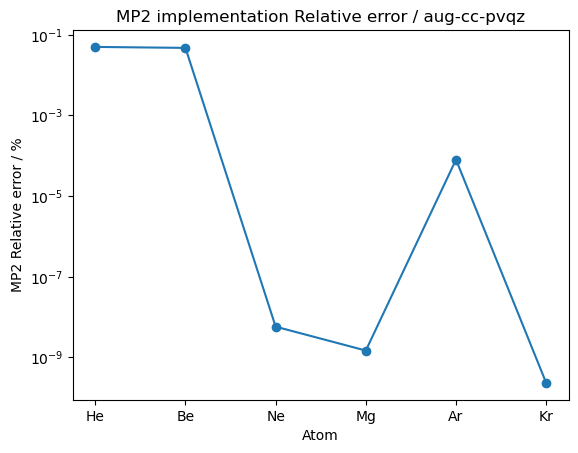

In [12]:
plt.plot(a_names, rel_errors, marker="o", linestyle="-")

plt.title(f"MP2 implementation Relative error / {basis}")
plt.yscale("log")
plt.ylabel("MP2 Relative error / %")
plt.xlabel("Atom")

plt.show()

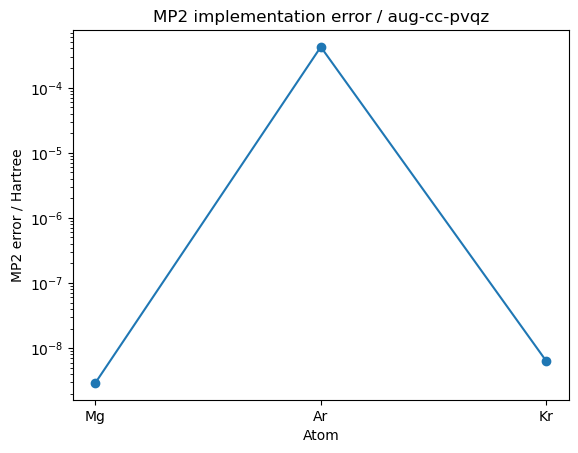

In [18]:
plt.plot(a_names[3:], np.array(abs_errors).real[3:], marker="o", linestyle="-")

plt.title(f"MP2 implementation error / {basis}")
plt.yscale('log')
plt.ylabel("MP2 error / Hartree")
plt.xlabel("Atom")

plt.show()